# Crosswalk: Anthropic Auto/Aug Task Scores → Occupation-Level Indices

Uses Anthropic's task-level automation vs augmentation breakdown
(from `automation_vs_augmentation_by_task.csv`) + O*NET crosswalk
to produce occupation-level AutoIndex and AssIndex.

Interaction types:
- **Automation** = `directive` + `feedback_loop`
- **Augmentation** = `task_iteration` + `validation` + `learning`
- `filtered` = unclassified (dropped)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Load data
tasks = pd.read_csv('../raw/Anthropic Task/automation_vs_augmentation_by_task.csv')
xwalk = pd.read_csv('../raw/Crosswalks/onet_task_statements.csv')

print(f'Task interaction data: {len(tasks)} tasks')
print(f'O*NET crosswalk: {len(xwalk)} task-occupation pairs')
print(f'Unique occupations: {xwalk["O*NET-SOC Code"].nunique()}')
print()
print('Task columns:', tasks.columns.tolist())
tasks.head()

Task interaction data: 3364 tasks
O*NET crosswalk: 19530 task-occupation pairs
Unique occupations: 974

Task columns: ['task_name', 'feedback_loop', 'directive', 'task_iteration', 'validation', 'learning', 'filtered']


,task_name,feedback_loop,directive,task_iteration,validation,learning,filtered
0,accept commissions to create music for special...,0.0,0.000000,0.000000,0.0,0.0,1.000000
1,act as advisers to student organizations.,0.0,0.382979,0.361702,0.0,0.0,0.255319
2,act as an advocate for farmers or farmers' gro...,0.0,0.000000,0.000000,0.0,0.0,1.000000
3,act as an intermediary in negotiations between...,0.0,0.391304,0.434783,0.0,0.0,0.173913
4,act as an intermediary in negotiations between...,0.0,0.391304,0.376812,0.0,0.0,0.231884


In [2]:
# ── Compute auto / ass scores per task ────────────────────────────────────────
# Automation = directive + feedback_loop
# Augmentation (ass) = task_iteration + validation + learning
tasks['auto_share'] = tasks['directive'] + tasks['feedback_loop']
tasks['ass_share']  = tasks['task_iteration'] + tasks['validation'] + tasks['learning']
tasks['classified'] = 1 - tasks['filtered']

# Normalize to exclude filtered (so auto + ass = 1 among classified)
tasks['auto_score'] = np.where(tasks['classified'] > 0,
                               tasks['auto_share'] / tasks['classified'], 0)
tasks['ass_score']  = np.where(tasks['classified'] > 0,
                               tasks['ass_share']  / tasks['classified'], 0)

print(f'Tasks with any classified usage: {(tasks["classified"] > 0).sum()}')
print(f'Mean auto_score (among classified): {tasks.loc[tasks["classified"]>0, "auto_score"].mean():.3f}')
print(f'Mean ass_score  (among classified): {tasks.loc[tasks["classified"]>0, "ass_score"].mean():.3f}')
print()
print('Quick check — auto + ass should ≈ 1:')
print((tasks['auto_score'] + tasks['ass_score']).describe())

Tasks with any classified usage: 2298
Mean auto_score (among classified): 0.357
Mean ass_score  (among classified): 0.643

Quick check — auto + ass should ≈ 1:
count    3364.000000
mean        0.683115
std         0.465331
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64


In [3]:
# ── Merge task scores onto crosswalk ──────────────────────────────────────────
# Lowercase both sides for matching
tasks['task_lower'] = tasks['task_name'].str.lower().str.strip()
xwalk['task_lower'] = xwalk['Task'].str.lower().str.strip()

merged = xwalk.merge(
    tasks[['task_lower', 'auto_score', 'ass_score', 'auto_share', 'ass_share', 'classified']],
    on='task_lower', how='left'
)

n_matched = merged['auto_score'].notna().sum()
print(f'Matched: {n_matched} / {len(merged)} ({100*n_matched/len(merged):.1f}%)')

# Fill unmatched with 0
for col in ['auto_score', 'ass_score', 'auto_share', 'ass_share', 'classified']:
    merged[col] = merged[col].fillna(0.0)

merged.head()

Matched: 4086 / 19530 (20.9%)


,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,task_lower,auto_score,ass_score,auto_share,ass_share,classified
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,87.0,07/2014,Incumbent,direct or coordinate an organization's financi...,0.377358,0.622642,0.347826,0.573913,0.921739
1,11-1011.00,Chief Executives,8831,Appoint department heads or managers and assig...,Core,87.0,07/2014,Incumbent,appoint department heads or managers and assig...,0.000000,0.000000,0.000000,0.000000,0.000000
2,11-1011.00,Chief Executives,8825,Analyze operations to evaluate performance of ...,Core,87.0,07/2014,Incumbent,analyze operations to evaluate performance of ...,0.323144,0.676856,0.312896,0.655391,0.968288
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,87.0,07/2014,Incumbent,"direct, plan, or implement policies, objective...",0.000000,0.000000,0.000000,0.000000,0.000000
4,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,87.0,07/2014,Incumbent,"prepare budgets for approval, including those ...",0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
# ── Also merge penetration scores ────────────────────────────────────────────
pen = pd.read_csv('../raw/Anthropic Task/task_penetration.csv')
pen['task_lower'] = pen['task'].str.lower().str.strip()

merged = merged.merge(pen[['task_lower', 'penetration']], on='task_lower', how='left')
merged['penetration'] = merged['penetration'].fillna(0.0)

print(f'Non-zero penetration: {(merged["penetration"] > 0).sum()} / {len(merged)}')

Non-zero penetration: 1667 / 19537


In [5]:
# ── Aggregate to occupation level ─────────────────────────────────────────────
# Weight: Core = 2, Supplemental = 1, × Incumbents Responding
merged['weight'] = np.where(merged['Task Type'] == 'Core', 2.0, 1.0)
merged['weight'] *= merged['Incumbents Responding'].fillna(1.0)

# Penetration-weighted: how much AI is used for auto vs ass tasks
# AutoIndex  = Σ (penetration × auto_score × w) / Σ w
# AssIndex   = Σ (penetration × ass_score  × w) / Σ w

def agg_occ(g):
    w = g['weight']
    pen = g['penetration']
    total_w = w.sum()
    return pd.Series({
        'automation_index':    (pen * g['auto_score'] * w).sum() / total_w,
        'augmentation_index':  (pen * g['ass_score']  * w).sum() / total_w,
        'mean_penetration':    (pen * w).sum() / total_w,
        'n_tasks': len(g),
        'n_tasks_classified': (g['classified'] > 0).sum(),
    })

occ_index = merged.groupby(['O*NET-SOC Code', 'Title']).apply(agg_occ).reset_index()

print(f'Occupation-level index: {len(occ_index)} occupations')
print(occ_index[['automation_index', 'augmentation_index', 'mean_penetration']].describe())
print()
print('Top 10 by automation_index:')
print(occ_index.nlargest(10, 'automation_index')[['Title', 'automation_index',
      'augmentation_index', 'mean_penetration']].to_string(index=False))
print()
print('Top 10 by augmentation_index:')
print(occ_index.nlargest(10, 'augmentation_index')[['Title', 'augmentation_index',
      'automation_index', 'mean_penetration']].to_string(index=False))

Occupation-level index: 974 occupations
       automation_index  augmentation_index  mean_penetration
count        974.000000          974.000000        974.000000
mean           0.024317            0.034661          0.076754
std            0.043378            0.060108          0.115601
min            0.000000            0.000000          0.000000
25%            0.000000            0.000000          0.000000
50%            0.000000            0.000000          0.000000
75%            0.029750            0.048442          0.107427
max            0.252707            0.430912          0.687133

Top 10 by automation_index:
                                             Title  automation_index  augmentation_index  mean_penetration
Market Research Analysts and Marketing Specialists          0.252707            0.321709          0.574415
                              Computer Programmers          0.251704            0.303919          0.662738
                        Bioinformatics Technicians  

In [6]:
# ── Export ────────────────────────────────────────────────────────────────────
occ_index['soc_code'] = occ_index['O*NET-SOC Code'].str.replace('.00', '', regex=False)

export_cols = ['soc_code', 'O*NET-SOC Code', 'Title', 'automation_index',
               'augmentation_index', 'mean_penetration', 'n_tasks']

occ_index[export_cols].to_csv('../output/data/anthropic_occ_index.csv', index=False)
print(f'Exported {len(occ_index)} occupations to output/data/anthropic_occ_index.csv')

Exported 974 occupations to output/data/anthropic_occ_index.csv


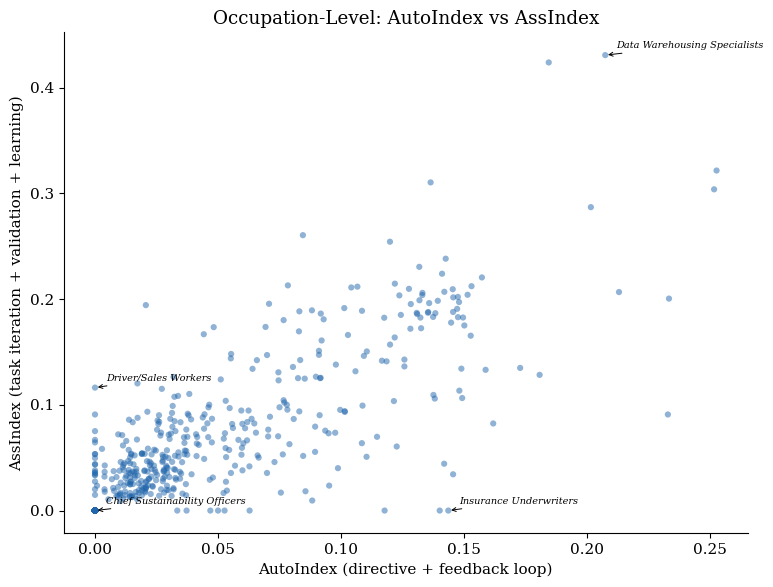

Done.


In [7]:
# ── Scatter: auto vs aug ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(occ_index['automation_index'], occ_index['augmentation_index'],
           s=20, alpha=0.5, color='#2166ac', edgecolors='none')

ax.set_xlabel('AutoIndex (directive + feedback loop)')
ax.set_ylabel('AssIndex (task iteration + validation + learning)')
ax.set_title('Occupation-Level: AutoIndex vs AssIndex')

# Label corners
med_a = occ_index['automation_index'].median()
med_s = occ_index['augmentation_index'].median()

corners = {
    'high ass, low auto': occ_index[
        (occ_index['augmentation_index'] > med_s) & (occ_index['automation_index'] <= med_a)
    ].nlargest(1, 'augmentation_index'),
    'high auto, low ass': occ_index[
        (occ_index['automation_index'] > med_a) & (occ_index['augmentation_index'] <= med_s)
    ].nlargest(1, 'automation_index'),
    'both high': occ_index[
        (occ_index['automation_index'] > med_a) & (occ_index['augmentation_index'] > med_s)
    ].nlargest(1, 'mean_penetration'),
    'both low': occ_index[
        (occ_index['automation_index'] <= med_a) & (occ_index['augmentation_index'] <= med_s)
    ].nsmallest(1, 'mean_penetration'),
}

for _, rows in corners.items():
    for _, row in rows.iterrows():
        label = row['Title'][:33] + '…' if len(row['Title']) > 35 else row['Title']
        ax.annotate(label,
                    xy=(row['automation_index'], row['augmentation_index']),
                    xytext=(8, 5), textcoords='offset points',
                    fontsize=7, fontstyle='italic',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.7))

plt.tight_layout()
plt.savefig('../output/graphs/descriptives/auto_vs_ass_scatter.pdf', bbox_inches='tight')
plt.show()
print('Done.')